<a href="https://colab.research.google.com/github/ayoub-bakr/RAG-Code/blob/main/MRAG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# تثبيت المكتبات مع تحديد إصدارات متوافقة لتقليل التعارض
!pip install requests==2.32.4 opentelemetry-api==1.38.0 opentelemetry-sdk==1.38.0
!pip install langchain langchain-community chromadb pypdf tiktoken sentence-transformers transformers accelerate --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.8/64.8 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.9/65.9 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.3/132.3 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.0/208.0 kB 15.8 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.33.1
    Uninstalling requests-2.33.1:
      Successfully uninstalled requests-2.33.1
  Attempting uninstall: opentelemetry-api
    Found existing installation: opentelemetry-api 1.40.0
    Uninstalling opentelemetry-api-1.40.0:
      Successfully uninstalled opentelemetry-api-1.40.0
  Attempting uninstall: opentelemetry-semantic-conventions
    Found existing installation: opentelemetry-semantic-conventions 0.61b0
    Uninstalling opentelemetry-semantic-conventions-0.61b0:
      Successfully uninstalled opentelemetry-semantic-conventions-0.61b0
  Attempting uninstall: opentelemetry-sdk
    Found e

In [6]:
import os
from langchain_community.document_loaders import PyPDFLoader
# تم تغيير المسار من langchain.text_splitter إلى langchain_text_splitters
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import Chroma
from langchain_community.llms import HuggingFacePipeline
from transformers import pipeline

In [7]:
loader = PyPDFLoader("/content/iso27001.pdf")
docs = loader.load()
print(f"Loaded {len(docs)} pages")

Loaded 26 pages


In [11]:
splitter = RecursiveCharacterTextSplitter(
    chunk_size=300,
    chunk_overlap=50
)
chunks = splitter.split_documents(docs)
print(f"Split into {len(chunks)} chunks")

Split into 248 chunks


In [22]:
print(chunks[0].page_content)

Information security, cybersecurity 
and privacy protection — Information 
security management systems — 
Requirements
Sécurité de l'information, cybersécurité et protection de la vie 
privée — Systèmes de management de la sécurité de l'information — 
Exigences
INTERNATIONAL 
STANDARD
ISO/IEC 
27001


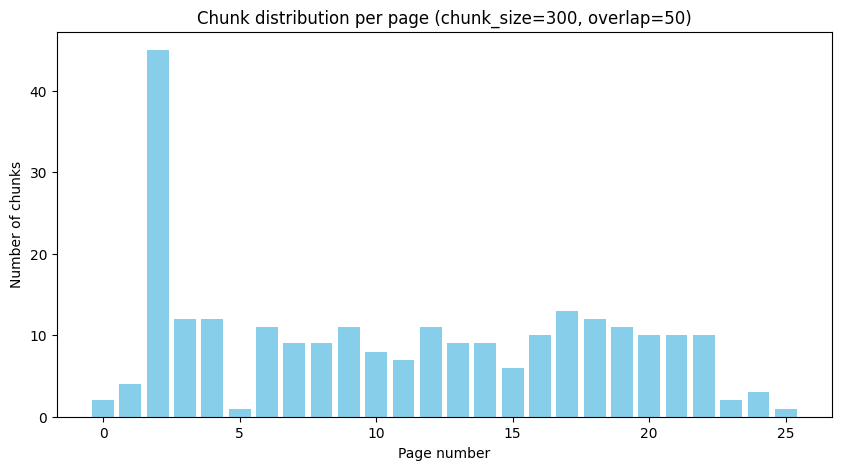

In [13]:
# visualization
import matplotlib.pyplot as plt

# تعريف القيم التي تم استخدامها في التقسيم
chunk_size = 300
chunk_overlap = 50

pages = [d.metadata.get("page", 0) for d in chunks]

unique_pages = sorted(set(pages))
counts_per_page = [pages.count(p) for p in unique_pages]

plt.figure(figsize=(10,5))
plt.bar(unique_pages, counts_per_page, color='skyblue')
plt.xlabel("Page number")
plt.ylabel("Number of chunks")
plt.title(f"Chunk distribution per page (chunk_size={chunk_size}, overlap={chunk_overlap})")
plt.show()

In [14]:
embedings = HuggingFaceEmbeddings( model_name="sentence-transformers/all-MiniLM-L6-v2")

/tmp/ipykernel_12480/3469936161.py:1: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embedings = HuggingFaceEmbeddings( model_name="sentence-transformers/all-MiniLM-L6-v2")
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.w

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [16]:
db = Chroma.from_documents(
    documents = chunks,
    embedding = embedings,
    persist_directory = "./chroma_db"
)
retriever = db.as_retriever(search_type = "mmr" ,  search_kwargs={"k": 5})

In [17]:
pipe = pipeline("text-generation", model="google/flan-t5-base", max_length=200)
llm = HuggingFacePipeline(pipeline=pipe)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

Passing `generation_config` together with generation-related arguments=({'max_length'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
The model 'T5ForConditionalGeneration' is not supported for text-generation. Supported models are ['PeftModelForCausalLM', 'AfmoeForCausalLM', 'ApertusForCausalLM', 'ArceeForCausalLM', 'AriaTextForCausalLM', 'BambaForCausalLM', 'BartForCausalLM', 'BertLMHeadModel', 'BertGenerationDecoder', 'BigBirdForCausalLM', 'BigBirdPegasusForCausalLM', 'BioGptForCausalLM', 'BitNetForCausalLM', 'BlenderbotForCausalLM', 'BlenderbotSmallForCausalLM', 'BloomForCausalLM', 'BltForCausalLM', 'CamembertForCausalLM', 'LlamaForCausalLM', 'CodeGenForCausalLM', 'CohereForCausalLM', 'Cohere2ForCausalLM', 'CpmAntForCausalLM', 'CTRLLMHeadModel', 'CwmForCausalLM', 'Data2VecTextForCausalLM', 'DbrxForCausalLM', 'DeepseekV2ForCausalLM', 'DeepseekV3ForCausalLM', 'DiffLlamaForCa

In [20]:
def ask(question):
    # Use .invoke() instead of the deprecated .get_relevant_documents()
    docs = retriever.invoke(question)
    context = "\n\n".join([f"{d.page_content}\n(Source: page {d.metadata.get('page', '?')})" for d in docs])

    prompt = f"""
Answer the question using ONLY the context below.
Cite the sources (page numbers).

Context:
{context}

Question:
{question}
"""
    return llm.generate([prompt]).generations[0][0].text

In [21]:
# test question
question = "What is this document about?"
answer = ask(question)
print(answer)


Answer the question using ONLY the context below.
Cite the sources (page numbers).

Context:
work.
The procedures used to develop this document and those intended for its further maintenance 
are described in the ISO/IEC Directives, Part 1. In particular, the different approval criteria 
needed for the different types of document should be noted. This document was drafted in
(Source: page 3)

document shall be controlled to ensure:
a) it is available and suitable for use, where and when it is needed; and
b) it is adequately protected (e.g. from loss of confidentiality, improper use, or loss of integrity).
(Source: page 12)

NOTE Determining these issues refers to establishing the external and internal context of the organization 
considered in Clause 5.4.1 of ISO 31000:2018[5].
4.2  Understanding the needs and expectations of interested parties
The organization shall determine:
(Source: page 6)

7.5.2  Creating and updating
When creating and updating documented information the organiz